# Eşdeğerlik Doğrulama — Polars (lazy) vs pandas

**Kanonik sorgu:** 2024 yılı iç hat uçuşları, `kalkis_havaalani` + `havayolu` bazında toplam gelir / ortalama gecikme / uçuş adedi.

Mantık `kanonik.py` modülünde; bu notebook onu import edip eşdeğerliği, edge-case'leri, süreyi ve görselleri sunar. (Birim testler: `tests/test_kanonik.py`.)

In [1]:
import hashlib
from kanonik import (polars_kanonik, pandas_kanonik, esdeger_mi,
                     sure_olc, VERI_YOLU, BEKLENEN_MD5)
import pandas as pd
import matplotlib.pyplot as plt

# --- Hücre A: girdi sabitleme (aynı baytlarla test edildiğini garanti et) ---
md5 = hashlib.md5(open(VERI_YOLU, 'rb').read()).hexdigest()
assert md5 == BEKLENEN_MD5, f'MD5 uyuşmazlığı: {md5}'
print('Girdi MD5 doğrulandı:', md5)

Girdi MD5 doğrulandı: a7a4ca24173b4f4b101c0ca70bf7a9d7


## Hücre B — Kanonik sorgu iki motorda
Polars LAZY (`scan_csv→filter→group_by→agg→sort→collect`) ve pandas eager (`read_csv→filter→groupby→agg→sort`).

In [2]:
pl_sonuc = polars_kanonik(VERI_YOLU)
pd_sonuc = pandas_kanonik(VERI_YOLU)
print('Polars şekil:', pl_sonuc.shape, '| pandas şekil:', pd_sonuc.shape)
pd_sonuc.head()

Polars şekil: (50, 5) | pandas şekil: (50, 5)


,kalkis_havaalani,havayolu,toplam_gelir,ort_gecikme_dk,ucus_adedi
0,IST,THY,16962276.01,20.150703,6828
1,IST,Pegasus,12640409.14,19.314925,5052
2,SAW,THY,9771611.58,20.297015,3919
3,SAW,Pegasus,7389227.12,19.594282,2938
4,IST,AnadoluJet,6346649.80,20.150294,2555


## Hücre C — Eşdeğerlik kanıtı
İki sonuç normalize edilir (aynı sıra, `ucus_adedi`→int64, float→float64), sonra: şekil / sütun / grup kümesi / int tam eşit / float toleranslı (`rtol=1e-9`).

In [3]:
rapor = esdeger_mi(pl_sonuc, pd_sonuc)
print('EŞDEĞERLİK:', 'PASS ✅' if rapor['gecti'] else 'FAIL ❌')
for k, v in rapor['detaylar'].items():
    print(f'  {k}: {v}')

EŞDEĞERLİK: PASS ✅
  sekil_esit: True
  sutunlar_esit: True
  grup_kumesi_esit: True
  ucus_adedi_tam_esit: True
  float_toleransli_esit: True
  gecti: True


## Hücre D — Edge case'ler (boş / null / tek satır)
Her senaryo iki motordan geçirilir; aynı davrandıkları doğrulanır.

In [4]:
import tempfile, os
BASLIK = 'ucus_no,kalkis_havaalani,varis_havaalani,havayolu,ucus_tipi,kalkis_tarihi,bilet_fiyati,gecikme_dk'

def mini(satirlar):
    f = tempfile.NamedTemporaryFile('w', suffix='.csv', delete=False)
    f.write('\n'.join([BASLIK] + satirlar) + '\n'); f.close(); return f.name

senaryolar = {
    'boş':              [],
    'null_filtre_dışı': ['F1,IST,ESB,THY,,2024-05-01,1000.0,10'],
    'tek_satır':        ['F1,IST,ESB,THY,ic_hat,2024-05-01,1000.0,10'],
}
for ad, satir in senaryolar.items():
    p = mini(satir)
    a = polars_kanonik(p); b = pandas_kanonik(p)
    esit = esdeger_mi(a, b)['gecti']
    print(f'{ad:18s} polars={a.shape} pandas={b.shape} eşit={esit}')
    os.unlink(p)

boş                polars=(0, 5) pandas=(0, 5) eşit=True
null_filtre_dışı   polars=(0, 5) pandas=(0, 5) eşit=True
tek_satır          polars=(1, 5) pandas=(1, 5) eşit=True


## Hücre E — Zaman ölçümü (N=5 tekrar ortalaması)
Tek-seferlik ölçüm gürültülüdür; 5 tekrar ortalaması alınır. Aynı kanonik sorgu, aynı tam girdi.

In [5]:
pl_sure = sure_olc(polars_kanonik, VERI_YOLU, tekrar=5)
pd_sure = sure_olc(pandas_kanonik, VERI_YOLU, tekrar=5)
print(f'Polars (lazy) ort: {pl_sure*1000:7.1f} ms')
print(f'pandas        ort: {pd_sure*1000:7.1f} ms')

Polars (lazy) ort:     5.0 ms
pandas        ort:    67.0 ms


## Hücre F — Görseller

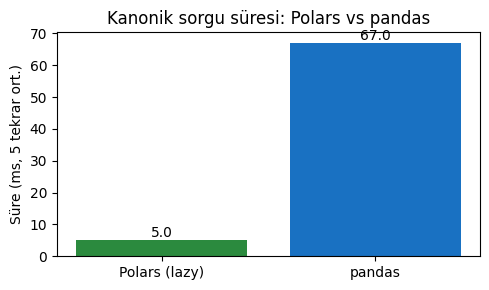

Kanonik sorgu sonucu (ilk 10 satır):


,kalkis_havaalani,havayolu,toplam_gelir,ort_gecikme_dk,ucus_adedi
0,IST,THY,16962276.01,20.150703,6828
1,IST,Pegasus,12640409.14,19.314925,5052
2,SAW,THY,9771611.58,20.297015,3919
3,SAW,Pegasus,7389227.12,19.594282,2938
4,IST,AnadoluJet,6346649.80,20.150294,2555
5,ESB,THY,4971087.01,19.695652,1978
6,ADB,THY,4916359.80,19.139949,1965
7,IST,SunExpress,4440984.49,20.748276,1740
8,AYT,THY,3901119.10,20.441290,1550
9,ADB,Pegasus,3801048.90,20.613395,1508


In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Polars (lazy)', 'pandas'], [pl_sure*1000, pd_sure*1000],
       color=['#2b8a3e', '#1971c2'])
ax.set_ylabel('Süre (ms, 5 tekrar ort.)')
ax.set_title('Kanonik sorgu süresi: Polars vs pandas')
for i, v in enumerate([pl_sure*1000, pd_sure*1000]):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

print('Kanonik sorgu sonucu (ilk 10 satır):')
pd_sonuc.head(10)